In [17]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Add plant_disease to path
sys.path.insert(0, str(Path.cwd().parent))

from plant_disease.utils.io import load_batch
from plant_disease.utils.color import bgr_to_hsv, bgr_to_rgb
from plant_disease.stage2_leaf_seg import (
    segment_leaf,
    apply_mask,
)

# Widget imports
from ipywidgets import IntSlider, HBox, VBox, Output, interactive_output

# Setup matplotlib
%matplotlib inline
plt.style.use('default')

print("✓ Imports successful")

✓ Imports successful


In [18]:
# Dataset paths
data_dir = Path("../data/selected")

# Categories
categories = [
    "tomato_healthy",
    "tomato_early_blight",
    "tomato_late_blight",
    "potato_healthy",
    "potato_early_blight",
    "potato_late_blight",
]

# Load images from each category (sample 3 per category for exploration = 18 total)
tuning_images = []

for category in categories:
    cat_dir = data_dir / category
    if cat_dir.exists():
        batch = load_batch(str(cat_dir), recursive=False)
        for path, img in batch[:3]:
            tuning_images.append((path, img, category))

print(f"✓ Loaded {len(tuning_images)} tuning images from {len(categories)} categories")
print(f"  Categories: {', '.join([cat.replace('_', ' ').title() for cat in categories])}")

✓ Loaded 18 tuning images from 6 categories
  Categories: Tomato Healthy, Tomato Early Blight, Tomato Late Blight, Potato Healthy, Potato Early Blight, Potato Late Blight


In [19]:
def apply_hsv_segmentation(
    image_bgr,
    h_min=35, h_max=85,
    s_min=30, s_max=255,
    v_min=40, v_max=255,
):
    hsv = bgr_to_hsv(image_bgr)
    if hsv is None:
        return None, None, 0
    
    result = segment_leaf(
        hsv,
        h_min=h_min, h_max=h_max,
        s_min=s_min, s_max=s_max,
        v_min=v_min, v_max=v_max,
        aplicar_morph=True
    )
    
    if result is None:
        return None, None, 0
    
    mask, area = result
    leaf_region = apply_mask(image_bgr, mask)
    
    return mask, leaf_region, area

print("✓ Helper functions defined")

✓ Helper functions defined


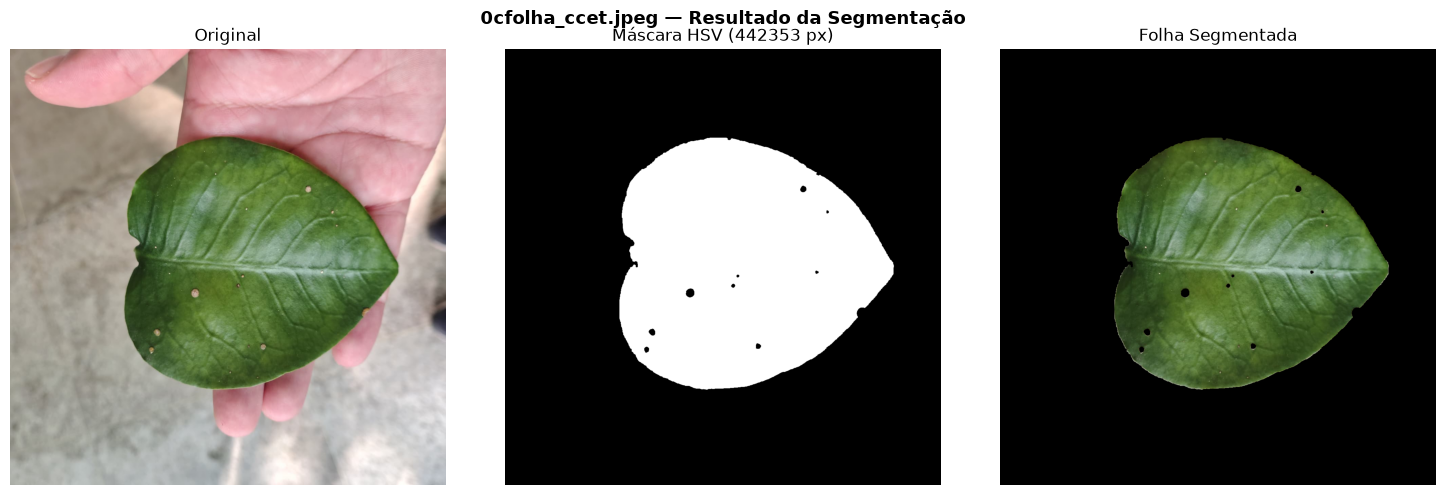

In [20]:
import cv2

# Carrega sua imagem específica
minha_img = cv2.imread("../data/selected/tomato_healthy/0cfolha_ccet.jpeg")

# Roda a segmentação com os parâmetros padrão
mask, leaf_region, area = apply_hsv_segmentation(minha_img)

# Plota os 3 resultados lado a lado
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(bgr_to_rgb(minha_img))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title(f"Máscara HSV ({area} px)")
axes[1].axis("off")

axes[2].imshow(bgr_to_rgb(leaf_region))
axes[2].set_title("Folha Segmentada")
axes[2].axis("off")

plt.suptitle("0cfolha_ccet.jpeg — Resultado da Segmentação", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

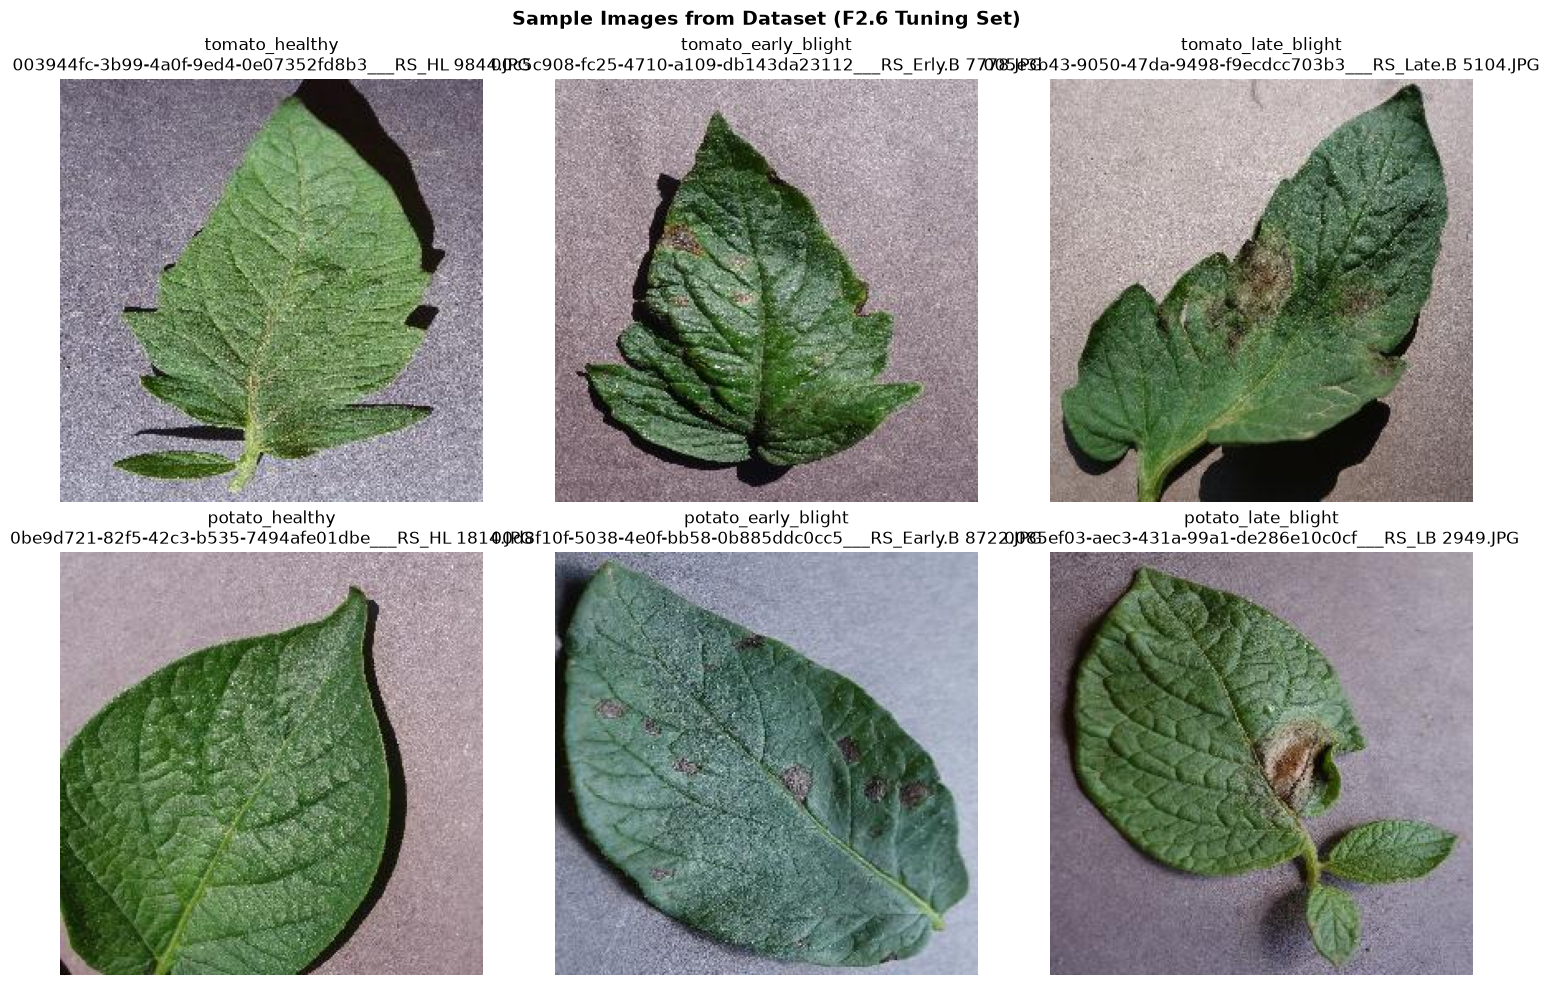

Dataset ready for tuning: 18 images


In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
sample_indices = [0, 3, 6, 9, 12, 15]

for idx, ax_idx in enumerate(sample_indices):
    if ax_idx < len(tuning_images):
        path, img_bgr, category = tuning_images[ax_idx]
        rgb = bgr_to_rgb(img_bgr)
        ax = axes[idx // 3, idx % 3]
        ax.imshow(rgb)
        ax.set_title(f"{category}\n{Path(path).name}")
        ax.axis("off")

plt.suptitle("Sample Images from Dataset (F2.6 Tuning Set)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Dataset ready for tuning: {len(tuning_images)} images")

In [22]:
h_min_slider = IntSlider(value=35, min=0, max=180, step=1, description="H min")
h_max_slider = IntSlider(value=85, min=0, max=180, step=1, description="H max")
s_min_slider = IntSlider(value=30, min=0, max=255, step=1, description="S min")
s_max_slider = IntSlider(value=255, min=0, max=255, step=1, description="S max")
v_min_slider = IntSlider(value=40, min=0, max=255, step=1, description="V min")
v_max_slider = IntSlider(value=255, min=0, max=255, step=1, description="V max")
image_idx_slider = IntSlider(value=0, min=0, max=len(tuning_images)-1, step=1, description="Image #")

output = Output()

def update_preview(h_min, h_max, s_min, s_max, v_min, v_max, image_idx):
    output.clear_output(wait=True)
    with output:
        path, img_bgr, category = tuning_images[image_idx]
        mask, leaf_region, area = apply_hsv_segmentation(
            img_bgr, h_min, h_max, s_min, s_max, v_min, v_max
        )
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        rgb = bgr_to_rgb(img_bgr)
        axes[0].imshow(rgb)
        axes[0].set_title("Original (RGB)")
        axes[0].axis("off")
        
        if mask is not None:
            axes[1].imshow(mask, cmap="gray")
            axes[1].set_title(f"HSV Mask (area: {area} px)")
        axes[1].axis("off")
        
        if leaf_region is not None:
            leaf_rgb = bgr_to_rgb(leaf_region)
            axes[2].imshow(leaf_rgb)
            axes[2].set_title("Extracted Leaf")
        axes[2].axis("off")
        
        plt.suptitle(f"Image #{image_idx}: {category}", fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.show()
        
        print(f"\n Current HSV Ranges:")
        print(f"  Hue (H):        [{h_min:3d} — {h_max:3d}]")
        print(f"  Saturation (S): [{s_min:3d} — {s_max:3d}]")
        print(f"  Value (V):      [{v_min:3d} — {v_max:3d}]")
        print(f"  Leaf Area:      {area} pixels | Image: {img_bgr.shape}")

interactive_preview = interactive_output(
    update_preview,
    {
        "h_min": h_min_slider, "h_max": h_max_slider,
        "s_min": s_min_slider, "s_max": s_max_slider,
        "v_min": v_min_slider, "v_max": v_max_slider,
        "image_idx": image_idx_slider,
    },
)

hue_box = HBox([h_min_slider, h_max_slider])
sat_box = HBox([s_min_slider, s_max_slider])
val_box = HBox([v_min_slider, v_max_slider])
sliders_box = VBox([hue_box, sat_box, val_box, image_idx_slider])

display(VBox([sliders_box, interactive_preview]))
print("\n💡 Tuning Guide: Ajuste sliders até isolar folhas verdes com mínimo ruído")


💡 Tuning Guide: Ajuste sliders até isolar folhas verdes com mínimo ruído



 Batch Testing com parâmetros: H[35-85] S[30-255] V[40-255]



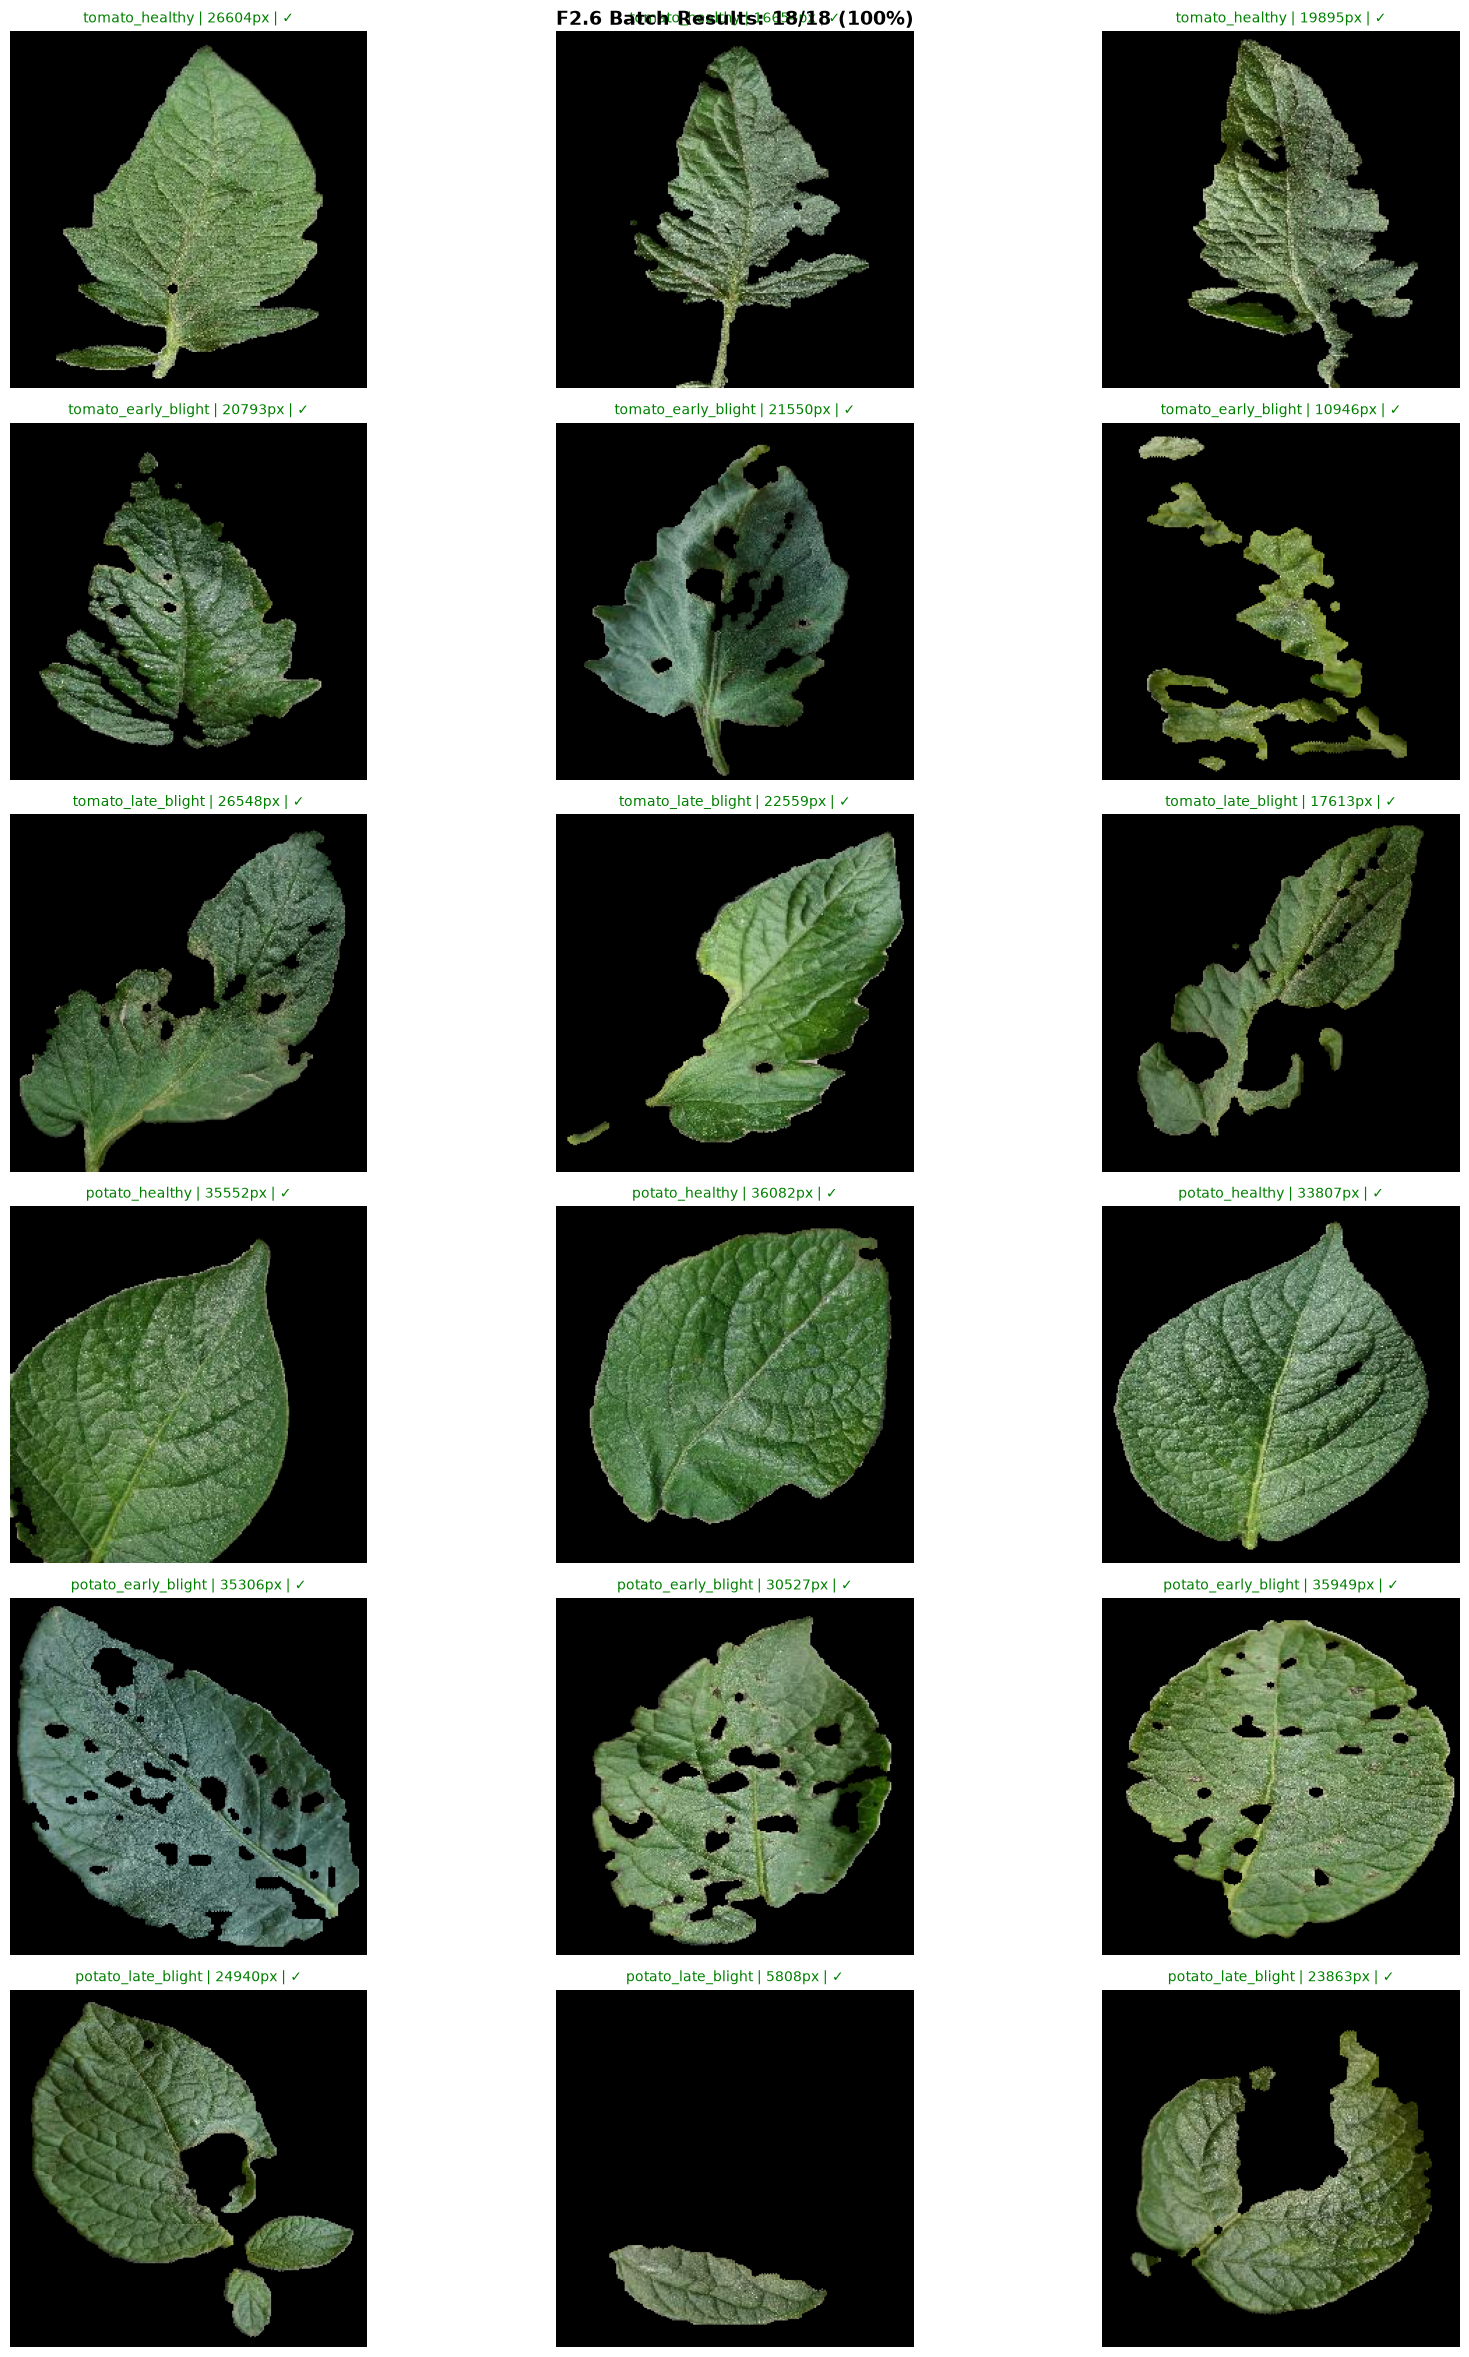

✓ Tuning Accuracy: 100.0%
  Status: PASSED ✓


In [23]:
best_h_min = h_min_slider.value
best_h_max = h_max_slider.value
best_s_min = s_min_slider.value
best_s_max = s_max_slider.value
best_v_min = v_min_slider.value
best_v_max = v_max_slider.value

print(f"\n Batch Testing com parâmetros: H[{best_h_min}-{best_h_max}] S[{best_s_min}-{best_s_max}] V[{best_v_min}-{best_v_max}]\n")

n_cols, n_rows = 3, (len(tuning_images) + 2) // 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))
axes = axes.flatten()

results_data, correct_count = [], 0

for idx, (path, img_bgr, category) in enumerate(tuning_images):
    mask, leaf_region, area = apply_hsv_segmentation(
        img_bgr, best_h_min, best_h_max, best_s_min, best_s_max, best_v_min, best_v_max
    )
    
    img_area = img_bgr.shape[0] * img_bgr.shape[1]
    visual_check = area > 1000 and area < img_area * 0.9
    if visual_check: correct_count += 1
    
    ax = axes[idx]
    if leaf_region is not None:
        leaf_rgb = bgr_to_rgb(leaf_region)
        ax.imshow(leaf_rgb)
    ax.set_title(f"{category} | {area}px | {'✓' if visual_check else '✗'}", 
                 color="green" if visual_check else "red", fontsize=10)
    ax.axis("off")
    
    results_data.append({"image": Path(path).name, "category": category, "area_px": area, "status": "✓" if visual_check else "✗"})

for idx in range(len(tuning_images), len(axes)):
    axes[idx].set_visible(False)

accuracy = (correct_count / len(tuning_images)) * 100
plt.suptitle(f"F2.6 Batch Results: {correct_count}/{len(tuning_images)} ({accuracy:.0f}%)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"✓ Tuning Accuracy: {accuracy:.1f}%") 
print(f"  Status: {'PASSED ✓' if accuracy >= 80 else 'NEEDS REVISION ✗'}")

In [24]:
print("\n Loading full dataset for F2.7 validation...\n")

validation_images = []
for category in categories:
    cat_dir = data_dir / category
    if cat_dir.exists():
        batch = load_batch(str(cat_dir), recursive=False)
        for i, (path, img) in enumerate(batch):
            if i % 5 == 0:  # Sample every 5th
                validation_images.append((path, img, category))

print(f"✓ Loaded {len(validation_images)} validation images\n")

validation_results, val_correct = [], 0

for path, img_bgr, category in validation_images:
    mask, leaf_region, area = apply_hsv_segmentation(
        img_bgr, best_h_min, best_h_max, best_s_min, best_s_max, best_v_min, best_v_max
    )
    
    img_area = img_bgr.shape[0] * img_bgr.shape[1]
    visual_check = area > 1000 and area < img_area * 0.9
    if visual_check: val_correct += 1
    
    validation_results.append({
        "image": Path(path).name, "category": category, "area_px": area,
        "h_min": best_h_min, "h_max": best_h_max,
        "s_min": best_s_min, "s_max": best_s_max,
        "v_min": best_v_min, "v_max": best_v_max,
        "acerto_visual": "SIM" if visual_check else "NÃO",
    })

val_accuracy = (val_correct / len(validation_images)) * 100

print(f"\n F2.7 VALIDATION FINAL:")
print(f"  Correct: {val_correct}/{len(validation_images)} ({val_accuracy:.1f}%)")
print(f"  Target: ≥80%")
print(f"  Status: {'✓✓✓ PASSED' if val_accuracy >= 80 else '✗ NEEDS REVISION'}\n")
print(f" Final HSV:")
print(f"  H ∈ [{best_h_min}, {best_h_max}] | S ∈ [{best_s_min}, {best_s_max}] | V ∈ [{best_v_min}, {best_v_max}]")

output_csv = Path("../results/f2_validation_results.csv")
output_csv.parent.mkdir(parents=True, exist_ok=True)
pd.DataFrame(validation_results).to_csv(output_csv, index=False)
print(f"\n Results saved to: {output_csv}")


 Loading full dataset for F2.7 validation...

✓ Loaded 61 validation images


 F2.7 VALIDATION FINAL:
  Correct: 61/61 (100.0%)
  Target: ≥80%
  Status: ✓✓✓ PASSED

 Final HSV:
  H ∈ [35, 85] | S ∈ [30, 255] | V ∈ [40, 255]

 Results saved to: ..\results\f2_validation_results.csv
